The sixth and final notebook in the STORM workflow turns to **temporal**
gene-program analysis: how each program's activity evolves across *developmental
time* and *space*.

Unlike tutorials 3-5, this notebook does **not** continue from the 2-timepoint
demo. It uses a separate, larger **5-timepoint** postnatal mouse-brain dataset
(Q43P0, Q43P2, Q43P5, C8P10, Q43P21) whose STORM model was trained on another
cluster following the *same* tutorial 1-5 pipeline. Only that run's saved
outputs are shipped here — the STORMed AnnDatas (with program activities already
encoded), the gene-program summary tables, and a few intermediate tables from
the temporal-clustering step. **No model checkpoint is needed**: every program
activity used below is read straight from the saved h5ads.

Those artifacts are staged into ``artifacts/storm_tutorial_5tmp/`` by
``examples/prepare_5tmp_inputs.py`` — run it once. It reads the saved run
read-only and restricts it to the corpus-callosum spatial-bin subset used for
the trajectory analysis.

By the end you will be able to:

1. load STORM program activities for a multi-timepoint dataset;
2. read the **temporal GP modules** — groups of programs that share a
   spatiotemporal activity trajectory along the postnatal corpus callosum;
3. draw each module's **developmental-time × spatial-bin trajectory** heatmap; and
4. draw per-program **spatial activity grids across the five timepoints**, the
   panel STORM uses to show a program's footprint sweeping across development.

# STORM tutorial 6: temporal gene-program analysis

STORM aligns timepoints in a shared latent space *without* erasing genuine
developmental change (tutorial 1), so a single set of gene programs can be
compared across ages. Applied to the postnatal corpus callosum, this recovers
**maturation trajectories** — programs that switch on, or migrate spatially, as
the tissue develops from P0 to P21.

| Input (staged under ``storm_tutorial_5tmp/``) | What it provides |
| --- | --- |
| ``{rna,atac}_5tmp_cc.h5ad`` | program activity (``X_storm_gp``) for corpus-callosum cells, with ``timepoint``, developmental ``time``, and spatial ``final_bin`` |
| ``gp_summary_{rna,atac}.csv`` | per-program member genes/peaks + learned weights |
| ``gp_temporal_modules.csv`` | each program's temporal module label (``R1``-``R6`` for RNA, ``A1``-``A8`` for ATAC) |
| ``{rna,atac}_module_trajectories.csv`` | precomputed mean module activity over (developmental time × spatial bin) |

Spatial grids are drawn with :func:`storm.programs.plot_spatial_gp_activity_grid`;
the trajectory heatmaps are a few lines of pandas.

In [1]:
import os
import sys

# Make the in-tree `storm/` package importable without a pip install.
_REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), os.pardir)) \
    if "__file__" in globals() else os.path.abspath(os.path.join(os.getcwd(), os.pardir))
for _candidate in (_REPO_ROOT, os.getcwd()):
    if os.path.isdir(os.path.join(_candidate, "storm")) and _candidate not in sys.path:
        sys.path.insert(0, _candidate)
        break

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import storm
from storm.programs import plot_spatial_gp_activity_grid

storm.plot.set_publication_params()

/gpfs/gibbs/project/zhao/xc384/conda_envs/storm/lib/python3.10/site-packages/torch/cuda/__init__.py:56: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 1. Parameters and paths

Run ``python examples/prepare_5tmp_inputs.py`` once to stage the inputs (it
reads the separate 5-timepoint run read-only). ``TIMEPOINTS`` are the
chronological ``obs['timepoint']`` values; ``DEV_TIME`` is the short
developmental-age label used by the trajectory tables.

In [2]:
DATA_DIR = "../artifacts/storm_tutorial_5tmp"
RNA_H5AD = f"{DATA_DIR}/rna_5tmp_cc.h5ad"
ATAC_H5AD = f"{DATA_DIR}/atac_5tmp_cc.h5ad"
GP_SUMMARY_RNA = f"{DATA_DIR}/gp_summary_rna.csv"
GP_SUMMARY_ATAC = f"{DATA_DIR}/gp_summary_atac.csv"
MODULES_CSV = f"{DATA_DIR}/gp_temporal_modules.csv"
RNA_TRAJ_CSV = f"{DATA_DIR}/rna_module_trajectories.csv"
ATAC_TRAJ_CSV = f"{DATA_DIR}/atac_module_trajectories.csv"

# Chronological timepoints + matching short developmental-age labels.
TIMEPOINTS = ["Q43P0", "Q43P2", "Q43P5", "C8P10", "Q43P21"]
DEV_TIME = ["P0", "P2", "P5", "P10", "P21"]
# Spatial bins run along the corpus-callosum axis.
SPATIAL_BINS = [3, 4, 5, 6, 7, 8, 9, 10]

## 2. Load the staged temporal-analysis inputs

The program activities are already in ``adata.obsm["X_storm_gp"]`` (and the
sign-corrected ``X_storm_gp_signc``), so there is no model or encoding step —
this notebook is pure analysis of the saved run.

In [3]:
rna = ad.read_h5ad(RNA_H5AD)
atac = ad.read_h5ad(ATAC_H5AD)

# Order rows by all_gp_idx so a program's column index in X_storm_gp matches
# its row in the summary table (the saved run keeps all programs active).
gp_summary_rna = pd.read_csv(GP_SUMMARY_RNA).sort_values("all_gp_idx").reset_index(drop=True)
gp_summary_atac = pd.read_csv(GP_SUMMARY_ATAC).sort_values("all_gp_idx").reset_index(drop=True)

print(f"RNA  CC cells: {rna.n_obs} x {rna.n_vars} genes; activity {rna.obsm['X_storm_gp'].shape}")
print(f"ATAC CC cells: {atac.n_obs} x {atac.n_vars} peaks; activity {atac.obsm['X_storm_gp'].shape}")
print("Timepoints :", sorted(rna.obs["timepoint"].astype(str).unique()))
print("Spatial bins:", sorted(rna.obs["final_bin"].unique()))

RNA  CC cells: 2256 x 5260 genes; activity (2256, 2554)
ATAC CC cells: 2256 x 5173 peaks; activity (2256, 2554)
Timepoints : ['C8P10', 'Q43P0', 'Q43P2', 'Q43P21', 'Q43P5']
Spatial bins: [3, 4, 5, 6, 7, 8, 9, 10]


## 3. Temporal gene-program modules

In the saved run, programs were clustered by their (developmental-time ×
spatial-bin) activity trajectory into **temporal modules** — ``R1``-``R6`` from
the RNA view and ``A1``-``A8`` from the ATAC view (each program carries a joint
``R_A`` label). Programs in the same module switch on at similar times and
places along the corpus callosum.

In [4]:
modules = pd.read_csv(MODULES_CSV)
modules.columns = ["gp", "joint_label"]
modules["gp_idx"] = modules["gp"].str.extract(r"GP_(\d+)").astype(int)
modules[["rna_module", "atac_module"]] = modules["joint_label"].str.split("_", n=1, expand=True)

rna_modules = {m: modules.loc[modules["rna_module"] == m, "gp_idx"].tolist()
               for m in ["R1", "R2", "R3", "R4", "R5", "R6"]}
atac_modules = {m: modules.loc[modules["atac_module"] == m, "gp_idx"].tolist()
                for m in [f"A{i}" for i in range(1, 9)]}

print("RNA modules:", {m: len(g) for m, g in rna_modules.items()})
print("ATAC modules:", {m: len(g) for m, g in atac_modules.items()})

RNA modules: {'R1': 67, 'R2': 42, 'R3': 7, 'R4': 6, 'R5': 5, 'R6': 2}
ATAC modules: {'A1': 71, 'A2': 3, 'A3': 37, 'A4': 6, 'A5': 4, 'A6': 4, 'A7': 2, 'A8': 2}


## 4. Module activity trajectories (developmental time × spatial bin)

The headline temporal view: for each RNA module, the mean program activity at
every (developmental time, corpus-callosum spatial bin). Top-to-bottom is
developmental time (P0 → P21); left-to-right is position along the corpus
callosum. Signal concentrated in the lower rows marks a late (P10-P21) program;
a hotspot that shifts column across rows is a wave of activity moving along the
tract as it matures.

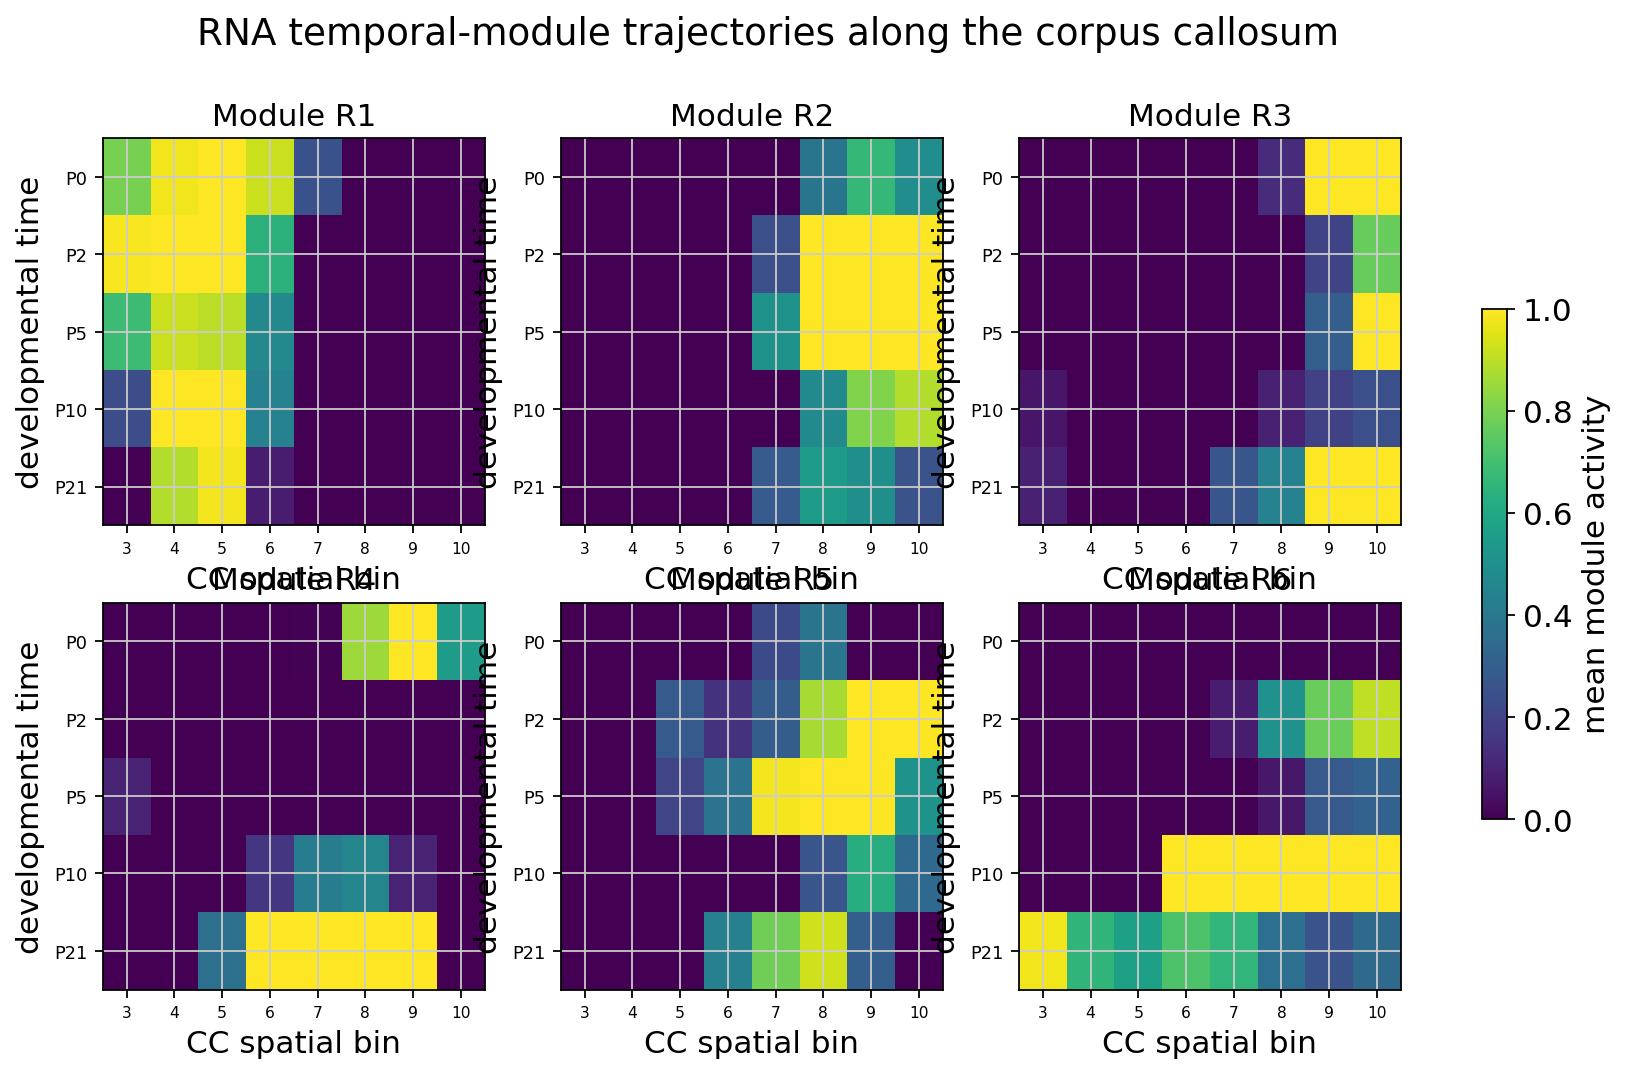

In [5]:
traj = pd.read_csv(RNA_TRAJ_CSV)
traj = traj[traj["modality"] == "RNA"]

mods = ["R1", "R2", "R3", "R4", "R5", "R6"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
im = None
for ax, m in zip(axes.ravel(), mods):
    mat = (traj[traj["variable"] == m]
           .pivot_table(index="Group.1", columns="Group.2", values="value")
           .reindex(index=DEV_TIME, columns=SPATIAL_BINS))
    im = ax.imshow(mat.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"Module {m}")
    ax.set_xticks(range(len(SPATIAL_BINS))); ax.set_xticklabels(SPATIAL_BINS, fontsize=7)
    ax.set_yticks(range(len(DEV_TIME))); ax.set_yticklabels(DEV_TIME, fontsize=8)
    ax.set_xlabel("CC spatial bin"); ax.set_ylabel("developmental time")
fig.colorbar(im, ax=axes, shrink=0.6, label="mean module activity")
fig.suptitle("RNA temporal-module trajectories along the corpus callosum", y=1.02)
fig.savefig(f"{DATA_DIR}/rna_module_trajectory_heatmaps.pdf", dpi=300, bbox_inches="tight")
plt.show()

### How a trajectory is computed

Each module's trajectory is just its programs' mean activity, averaged over the
cells in each (time, bin) group. Recomputing one module straight from
``X_storm_gp`` reproduces the same spatiotemporal pattern (the precomputed table
additionally min-max-normalises each module, so only the *shape* is meant to
match, not the absolute scale).

/gpfs/gibbs/project/zhao/xc384/conda_cache/tmp/ipykernel_1894900/3819103616.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["time", "bin"])["act"].mean()


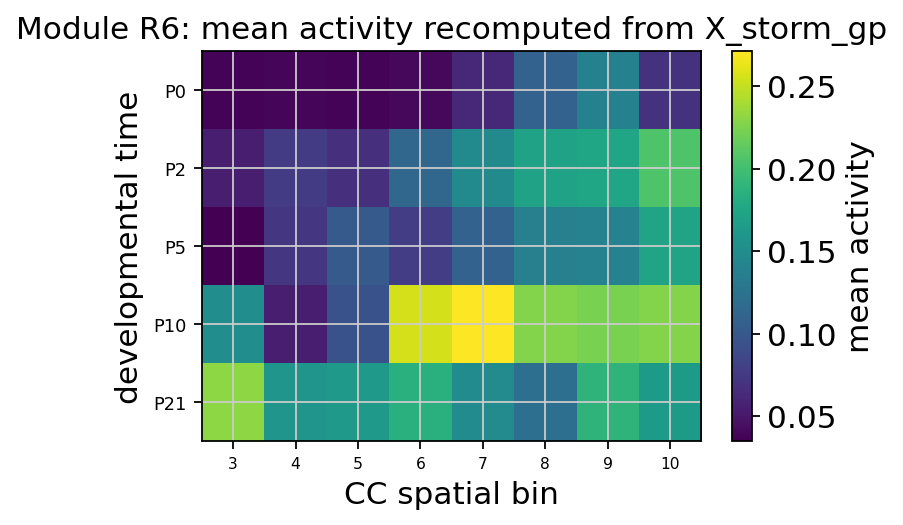

In [6]:
m = "R6"
act = np.asarray(rna.obsm["X_storm_gp"][:, rna_modules[m]]).mean(axis=1).ravel()
recomputed = (
    pd.DataFrame({"time": rna.obs["time"].values,
                  "bin": rna.obs["final_bin"].values, "act": act})
      .groupby(["time", "bin"])["act"].mean()
      .reset_index()
      .pivot(index="time", columns="bin", values="act")
      .reindex(index=DEV_TIME, columns=SPATIAL_BINS)
)
fig, ax = plt.subplots(figsize=(5, 3.2))
im = ax.imshow(recomputed.values, aspect="auto", cmap="viridis")
ax.set_title(f"Module {m}: mean activity recomputed from X_storm_gp")
ax.set_xticks(range(len(SPATIAL_BINS))); ax.set_xticklabels(SPATIAL_BINS, fontsize=7)
ax.set_yticks(range(len(DEV_TIME))); ax.set_yticklabels(DEV_TIME, fontsize=8)
ax.set_xlabel("CC spatial bin"); ax.set_ylabel("developmental time")
fig.colorbar(im, ax=ax, label="mean activity")
plt.show()

## 5. Spatial program activity across the five timepoints

For a representative program from each module, draw its spatial activity at
each timepoint (rows = P0 → P21, columns = programs). Activity is z-scored per
program and averaged within each corpus-callosum spatial bin for a clean
read-out — exactly what :func:`storm.programs.plot_spatial_gp_activity_grid`
does with ``normalise="zscore", bin_key="final_bin"``. This is the panel that
makes a program's developmental sweep visible.

Representative programs:
  R1: GP 2160  (Nfib_TF_target_genes_GP)
  R2: GP 968  (Icosl_ligand_receptor_target_gene_GP)
  R4: GP 455  (Bdnf_ligand_receptor_target_gene_GP)
  R5: GP 581  (Cdh6_ligand_receptor_target_gene_GP)
  R6: GP 1301  (Pdgfa_ligand_receptor_target_gene_GP)


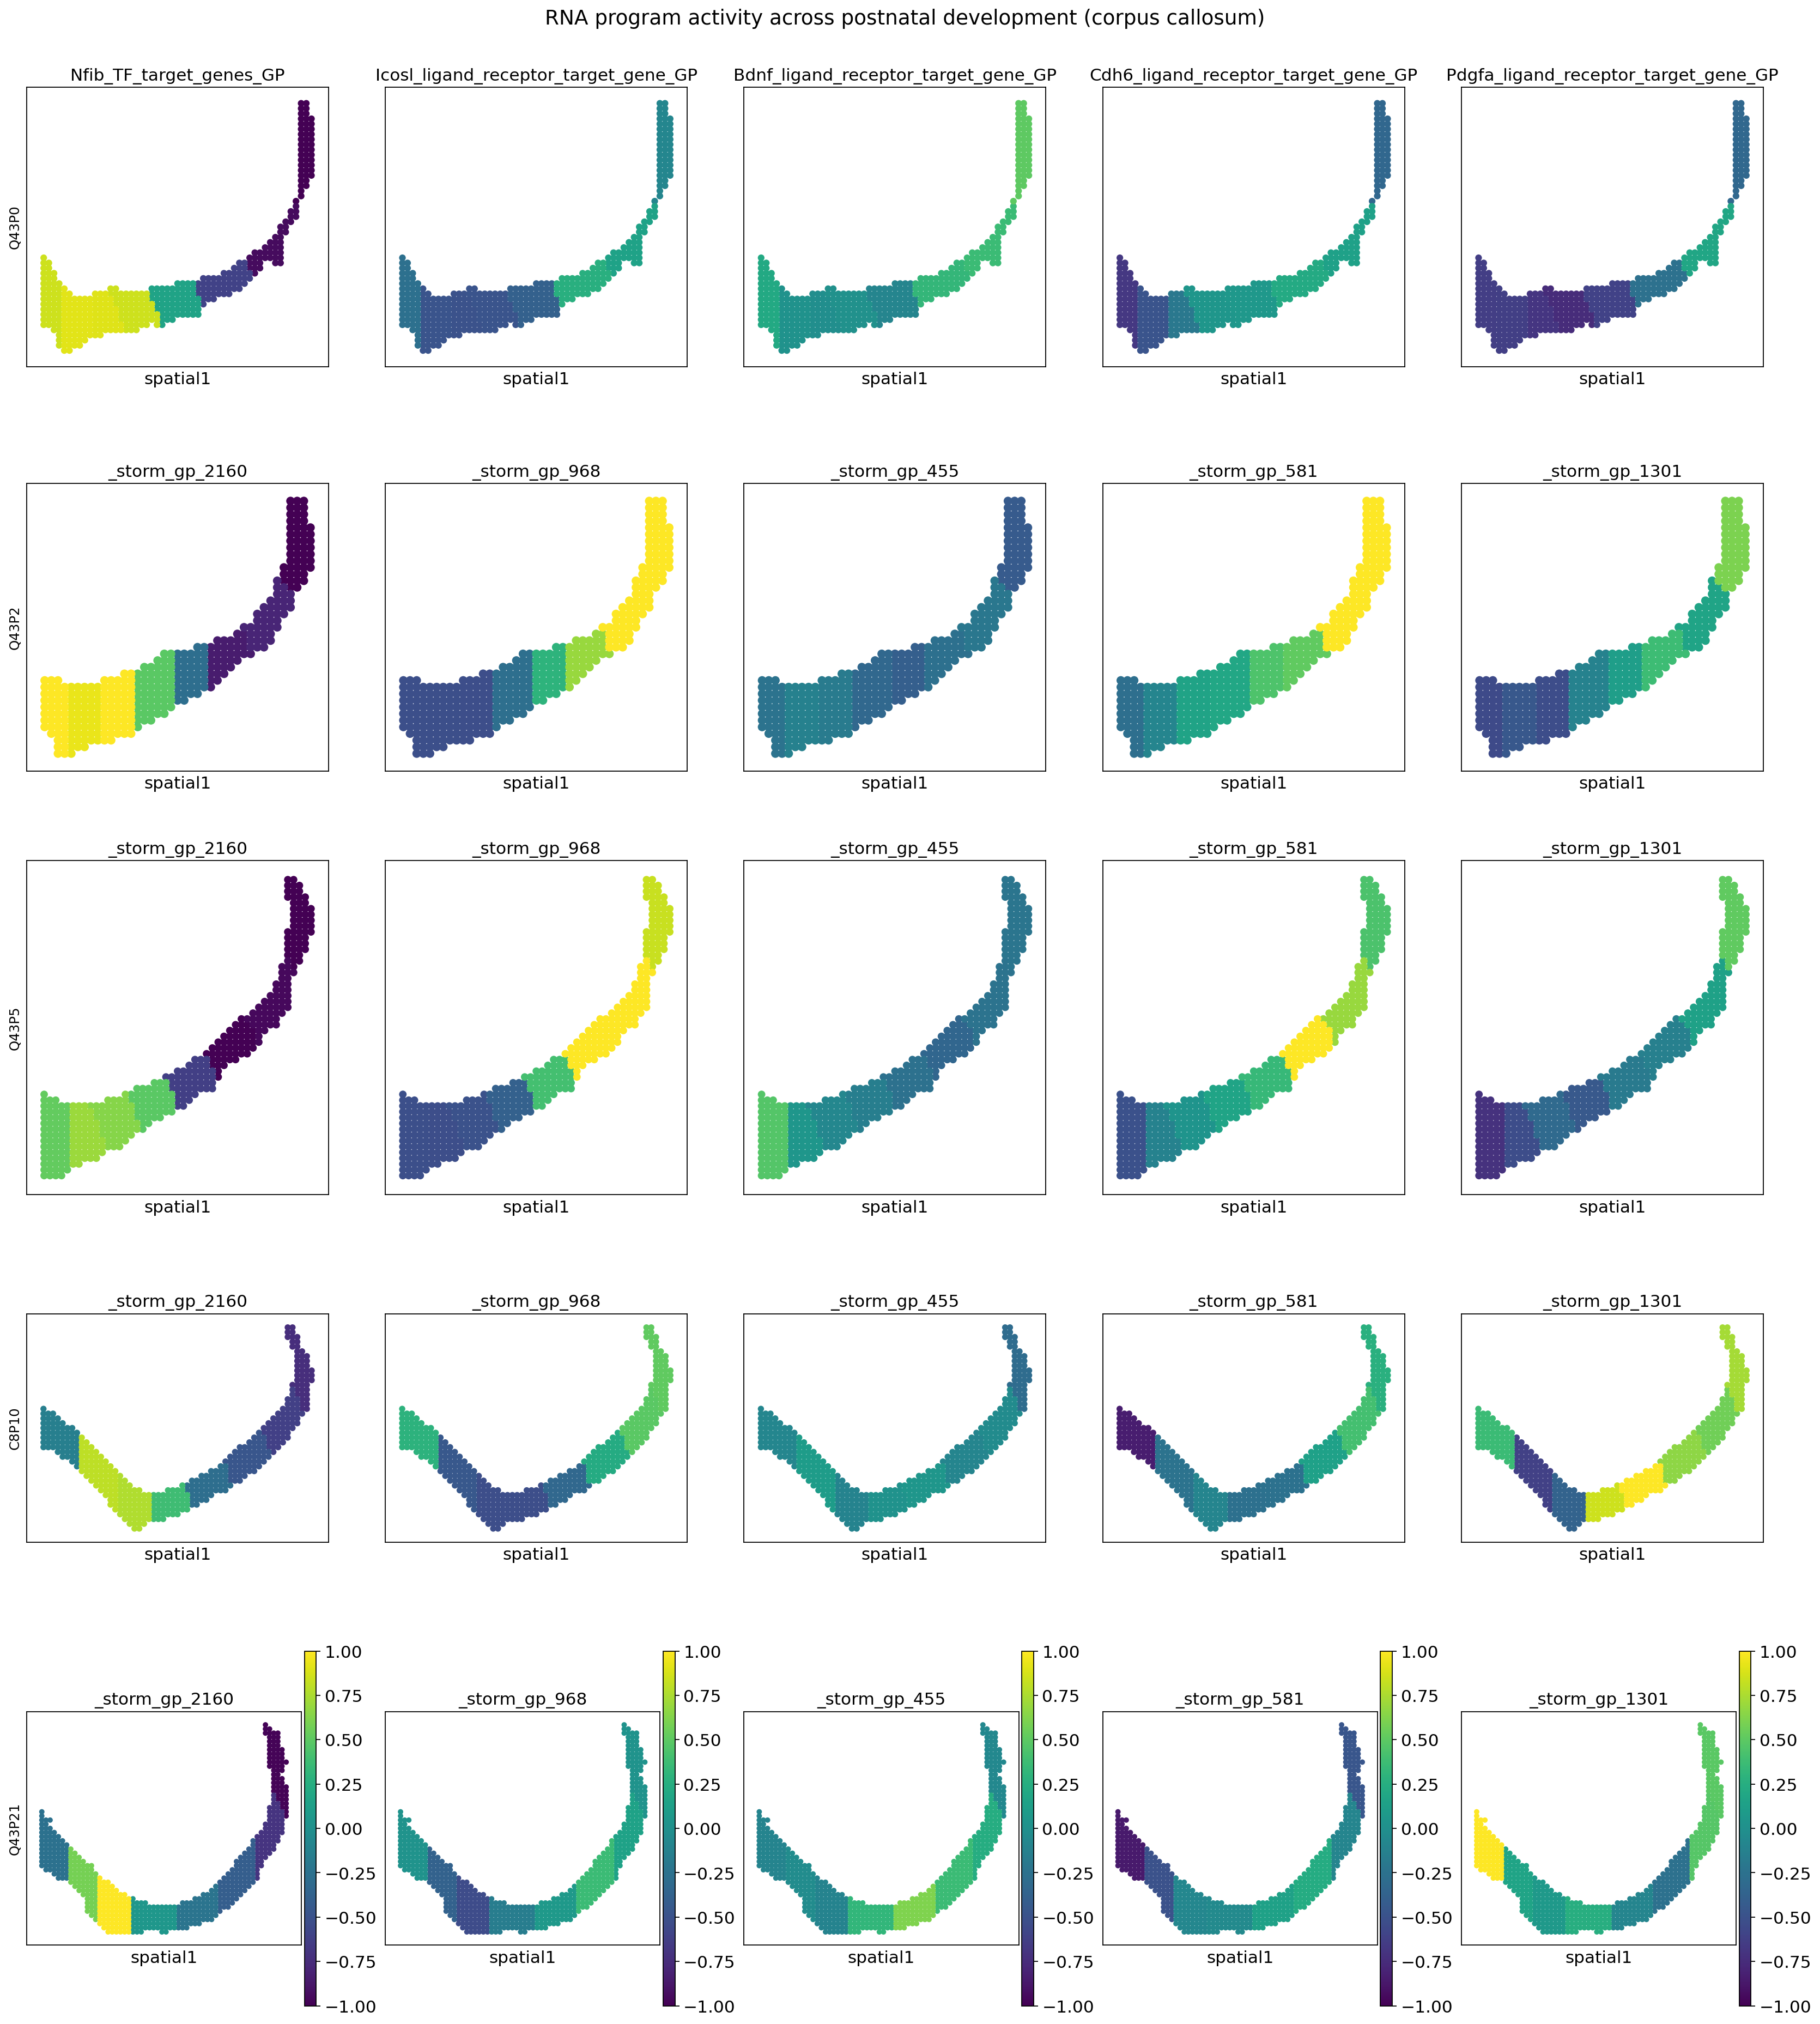

In [7]:
# One representative program per module, each anchored by a known marker gene.
representatives = {
    "R1": 2160,   # Nfib  (early progenitor / radial-glia program)
    "R2": 968,
    "R4": 455,    # Bdnf
    "R5": 581,    # Cdh6
    "R6": 1301,   # Pdgfa / Mbp-associated (late myelination program)
}
rep_gps = list(representatives.values())
print("Representative programs:")
for mod, gp in representatives.items():
    print(f"  {mod}: GP {gp}  ({gp_summary_rna.iloc[gp]['gp_name']})")

fig = plot_spatial_gp_activity_grid(
    rna, rep_gps, TIMEPOINTS,
    gp_summary=gp_summary_rna,
    gp_key="X_storm_gp",
    timepoint_key="timepoint",
    normalise="zscore",
    bin_key="final_bin",
    vmin=-1, vmax=1,
    spot_size=1.3,
)
fig.suptitle("RNA program activity across postnatal development (corpus callosum)", y=1.01)
fig.savefig(f"{DATA_DIR}/rna_temporal_spatial_grid.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 6. The ATAC view

The same analysis runs on the ATAC program activities and their ``A1``-``A8``
modules. The module trajectories are below; the spatial grid works identically
on ``atac`` with ``gp_summary_atac`` (pass any column indices from
``atac_modules``).

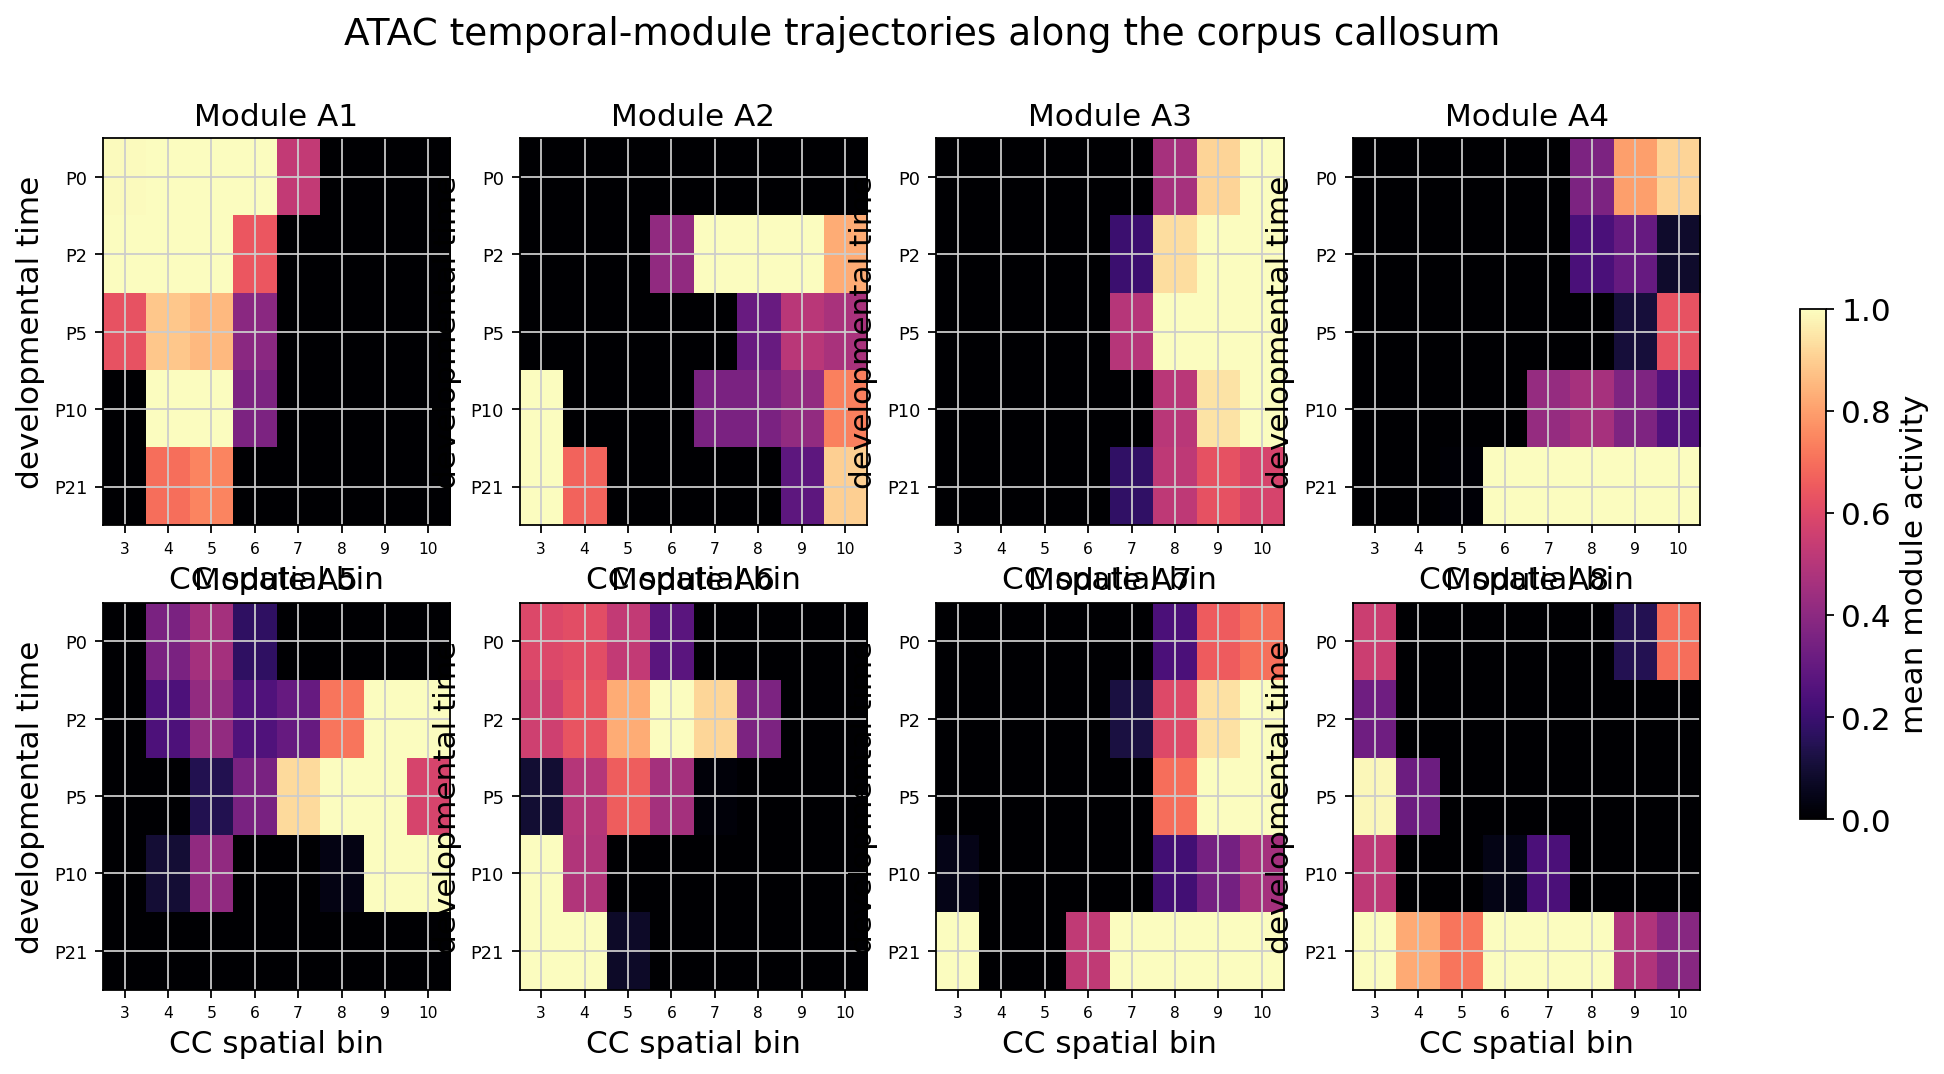

In [8]:
traj_a = pd.read_csv(ATAC_TRAJ_CSV)
traj_a = traj_a[traj_a["modality"] == "ATAC"]

amods = [f"A{i}" for i in range(1, 9)]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
im = None
for ax, m in zip(axes.ravel(), amods):
    mat = (traj_a[traj_a["variable"] == m]
           .pivot_table(index="Group.1", columns="Group.2", values="value")
           .reindex(index=DEV_TIME, columns=SPATIAL_BINS))
    im = ax.imshow(mat.values, aspect="auto", cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"Module {m}")
    ax.set_xticks(range(len(SPATIAL_BINS))); ax.set_xticklabels(SPATIAL_BINS, fontsize=7)
    ax.set_yticks(range(len(DEV_TIME))); ax.set_yticklabels(DEV_TIME, fontsize=8)
    ax.set_xlabel("CC spatial bin"); ax.set_ylabel("developmental time")
fig.colorbar(im, ax=axes, shrink=0.6, label="mean module activity")
fig.suptitle("ATAC temporal-module trajectories along the corpus callosum", y=1.02)
fig.savefig(f"{DATA_DIR}/atac_module_trajectory_heatmaps.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 7. What to look for

* **Late-activating modules** — signal concentrated in the P10/P21 rows marks
  programs that switch on as the corpus callosum matures (e.g. the
  myelination program anchored by *Pdgfa*/*Mbp*).
* **Spatial waves** — a hotspot that shifts bin position across rows indicates
  activity propagating along the tract over developmental time.
* **RNA vs ATAC modules** — when a program's RNA module (``R``) and ATAC module
  (``A``) trajectories differ, transcription is leading or lagging chromatin
  accessibility — the kind of cross-modality, cross-time comparison STORM is
  built for.

Because the activities are precomputed and saved, this notebook reproduces the
temporal figures without the original model or training cluster. Re-run
``examples/prepare_5tmp_inputs.py`` if you need to re-stage the inputs.